In [1]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton
from time import time
import torch
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # For parallel execution



In [2]:
# File paths
old_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/Old equations/datasets/trials_many_alldata_v3.h5"
new_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_3000.h5"

In [3]:
# with h5py.File(old_file_path, 'r') as old_data:
#     # Extract parameter values
#     P_old = old_data['P'][:]
#     J_e_primes = P_old[:, 0]
#     b_1_primes = P_old[:, 1]
#     b_2_primes = P_old[:, 2]
#     f_0_primes = P_old[:, 6]

#     # Find the shortest length
#     min_length = min(len(J_e_primes), len(b_1_primes), len(b_2_primes), len(f_0_primes))
#     # Function to randomly reduce the length of a list
#     def reduce_length(arr, target_length):
#         if len(arr) > target_length:
#             indices = np.random.choice(len(arr), target_length, replace=False)
#             return arr[indices]
#         return arr

#     # Reduce lengths to the shortest length
#     J_e_primes = reduce_length(J_e_primes, min_length)
#     b_1_primes = reduce_length(b_1_primes, min_length)
#     b_2_primes = reduce_length(b_2_primes, min_length)
#     f_0_primes = reduce_length(f_0_primes, min_length)
#     f_cr = 5.3e-3
#     f_0_values = f_0_primes/f_cr
#     # h_0_values = P_old[:, 4]

# time_grid = np.linspace(0, 1, 601)

In [4]:
# print(J_e_primes.min(), J_e_primes.max())
# print(b_1_primes.min(), b_1_primes.max())
# print(b_2_primes.min(), b_2_primes.max())
# print(f_0_values.min(), f_0_values.max())
# print(h_0_values.min(), h_0_values.max())

Constants

In [5]:
halton_sampler = Halton(d=1, scramble=False, seed=42)
halton_sequence = halton_sampler.random(n=111563).flatten()

ts_range = [10., 60.] # Characteristic time scale (s)
ts_halton = ts_range[0] + (ts_range[1] - ts_range[0]) * halton_sequence

h_range = [2e-6, 8e-6] # Characteristic height (m)
h_0_values = h_range[0] + (h_range[1] - h_range[0]) * halton_sequence

J_e_range = [0., 40e-6] # Characteristic evaporation rate (m/minute)
J_e_primes = J_e_range[0] + (J_e_range[1] - J_e_range[0]) * halton_sequence
J_e_primes = J_e_primes / 60. # Convert to m/s
J_e_values = J_e_primes * ts_halton / h_0_values

f_0_range = [0.08, 0.2] # Characteristic fluorescence (%)
f_cr = 5.3e-3 # Critical fluorescence (%)
f_0_primes = f_0_range[0] + (f_0_range[1] - f_0_range[0]) * halton_sequence
f_0_values = f_0_primes / f_cr

b_1_range = [-2., 2.] # (s^-1)
b_1_primes = b_1_range[0] + (b_1_range[1] - b_1_range[0]) * halton_sequence
b_1_values = b_1_primes * ts_halton

b_2_range = [0., 2.] # (s^-1)
b_2_primes = b_2_range[0] + (b_2_range[1] - b_2_range[0]) * halton_sequence
b_2_values = b_2_primes * ts_halton

# Rescale to be in the range 0.5 to 1.0
h_e_range = [0.5e-6, 1e-6] # Characteristic height (m)
h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sequence
h_e_values = np.array(h_e_halton) / np.array(h_0_values)


In [6]:
rho = 1e3 # Water density (g/L)
P_c_hat = 12.1e-6 # (m/s)
Vw = 18e-6 # Molar volume of water (m^3/Mol)
c_0 = 300 # Serum Osmolarity (Mol/m^3)
sigma_0 = 0.045 # N/m
mu = 1.3e-3 # Pa.s

# Solute parameters
Mw_FL = 376e-3 # molecular weight of Na_2FL, (Kg/mol)

# Naperian extinction coefficient
eps_f = 1.75e7 # m^-1 M^-1
# transmittance parameter
fcr2 = rho * f_cr/Mw_FL


In [7]:
phi_values = eps_f*fcr2*h_0_values
Pc_values = P_c_hat*Vw*c_0/J_e_values

C:\Users\arnab\AppData\Local\Temp\ipykernel_21612\2259545292.py:2: RuntimeWarning: divide by zero encountered in divide
  Pc_values = P_c_hat*Vw*c_0/J_e_values


In [8]:
# Function to calculate I
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


In [9]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e, P_c):
    h, c = y
    g_t = b_1 * np.exp(-b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = -g_t * c - dh_dt * (c / h)
    return [dh_dt, dc_dt]

def generate_and_store_dataset():  
    valid_h, valid_c, valid_f, valid_I, valid_p = [], [], [], [], []
    time_grid = np.linspace(0, 1, 601)  # Time grid for integration
    fixed_length = len(time_grid) 
    
    def solve_single_instance(i):
        J_e, b_1, b_2, h_e, f_0, Pc, phi = (J_e_values[i], b_1_values[i], b_2_values[i],
                                            h_e_values[i], f_0_values[i], Pc_values[i], phi_values[i])
        y0 = [1.0, 1.0]
        sol = solve_ivp(differential_system, [0., 1.], y0, t_eval=time_grid, 
                        args=(J_e, b_1, b_2, h_e, Pc), method='LSODA')  # Faster for stiff equations
        
        if np.max(sol.y[0]) > 1.1:
            return None  # Skip rejected cases
        elif sol.y[0].shape[0] < fixed_length:
            return None
        else:
            h = sol.y[0]
            c = sol.y[1] / sol.y[0]
            f = f_0 * c
            FI = ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
            I0 = 1 / FI[1]
            I = I0 * ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
            return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi)

    results = Parallel(n_jobs=-1)(delayed(solve_single_instance)(i) for i in range(1000))
    filtered_results = [res for res in results if res is not None]
    print(len(filtered_results[0]))

    # Unpacking results into numpy arrays for efficient storage
    valid_h, valid_c, valid_f, valid_I, valid_p = map(np.array, zip(*filtered_results))

    # Convert lists to NumPy arrays
    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    valid_p = np.array(valid_p)

    # Save data in HDF5 format
    with h5py.File(new_file_path, "w") as hdf_file:
        hdf_file.create_dataset("h", data=valid_h)
        hdf_file.create_dataset("c", data=valid_c)
        hdf_file.create_dataset("f", data=valid_f)
        hdf_file.create_dataset("I", data=valid_I)
        hdf_file.create_dataset("p", data=valid_p)
        
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")
    return valid_h, valid_c, valid_f, valid_I, valid_p


In [10]:
start = time()
valid_h, valid_c, valid_f, valid_I, valid_p = generate_and_store_dataset()
end = time()
print(f"Time taken: {end - start:.2f} seconds")

5
Total accepted parameter sets: 556
Time taken: 12.63 seconds


In [11]:
datastore = h5py.File(new_file_path, 'r')
data_I = np.array(datastore["I"])
data_h = np.array(datastore["h"])
data_f = np.array(datastore["f"])

data_c = np.array(datastore["c"])

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
# device = "cpu"
print(f"Using {device} device")

Using cpu device


In [12]:
t = np.linspace(0,1,601)

543
Parameters for n=543:
J_e: 4.8361165649200615
b_1: 109.89032745361328
b_2: 113.43149185180664
h_e: 0.12596802398201348
f_0: 37.05041273584906
P_c: 1.3510840593454563e-08
phi: 1928.5979575299198


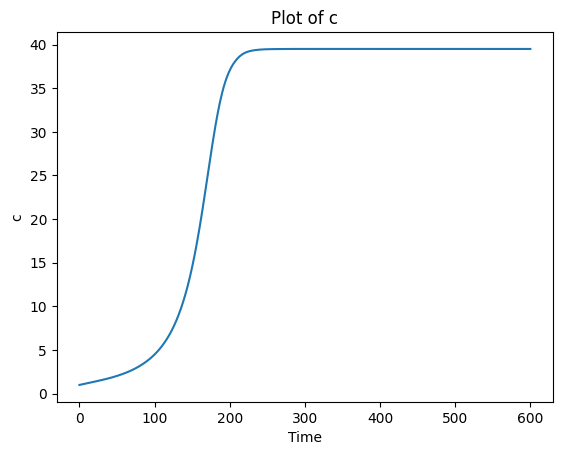

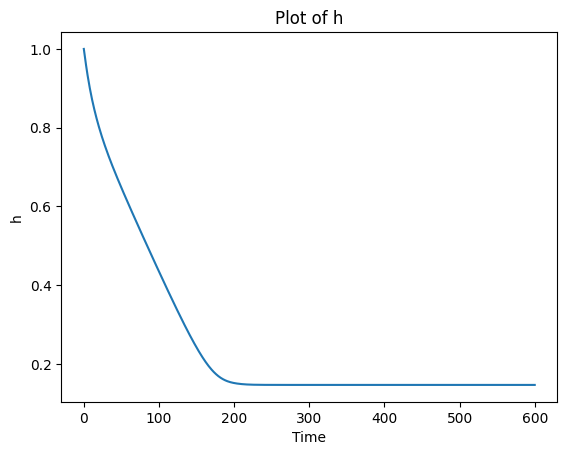

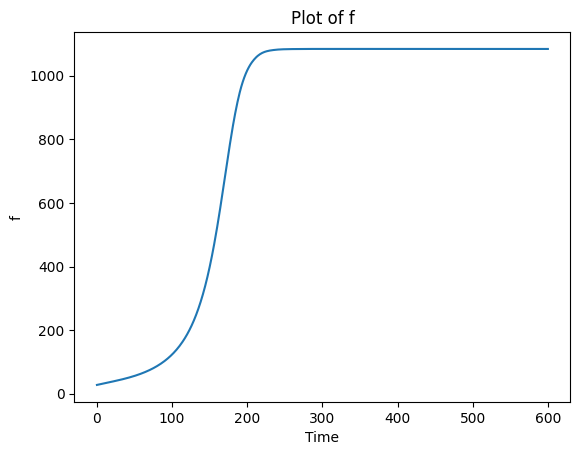

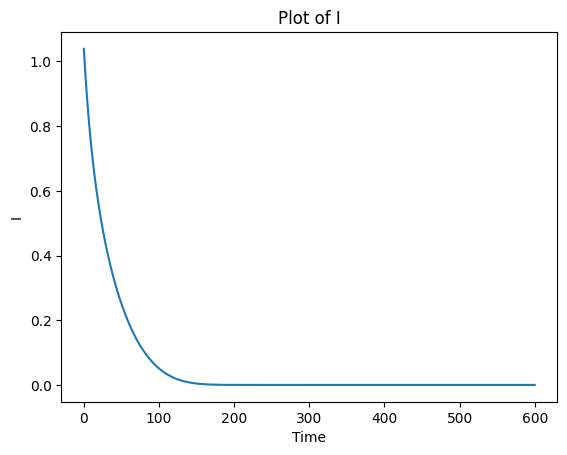

In [16]:
n = np.random.randint(0, len(data_h))
print(n)
print(f"Parameters for n={n}:")
print(f"J_e: {J_e_values[n]}")
print(f"b_1: {b_1_values[n]}")
print(f"b_2: {b_2_values[n]}")
print(f"h_e: {h_e_values[n]}")
print(f"f_0: {f_0_values[n]}")
print(f"P_c: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

242
Parameters for n=242:
J_e: 1.3583132606490873
b_1: -19.4696044921875
b_2: 15.69488525390625
h_e: 0.16987829614604466
f_0: 22.0813679245283
P_c: 4.810377833518054e-08
phi: 950.0862283909572


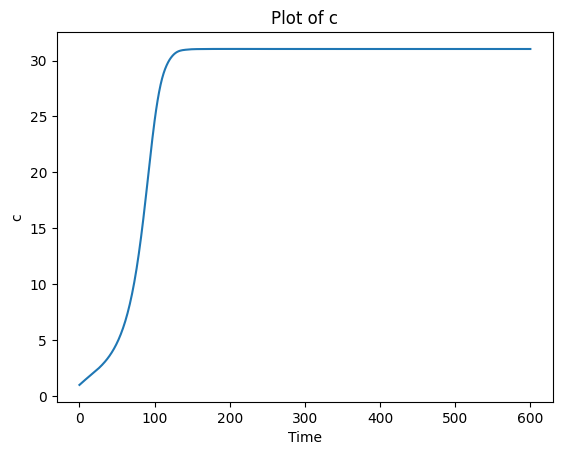

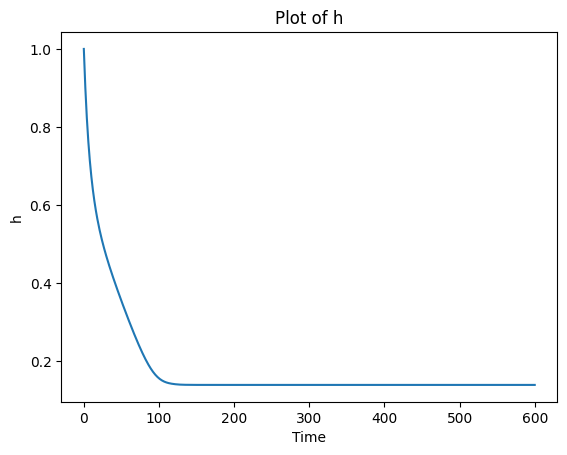

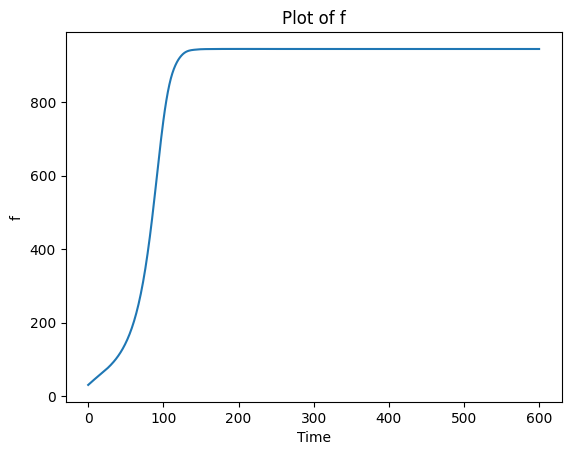

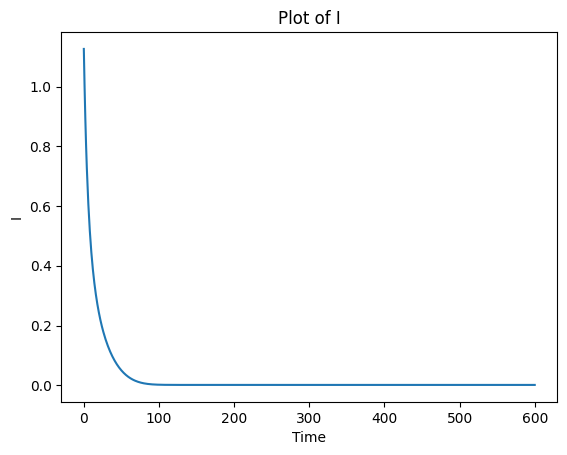

In [14]:
n = np.random.randint(0, len(data_h))
print(n)
print(f"Parameters for n={n}:")
print(f"J_e: {J_e_values[n]}")
print(f"b_1: {b_1_values[n]}")
print(f"b_2: {b_2_values[n]}")
print(f"h_e: {h_e_values[n]}")
print(f"f_0: {f_0_values[n]}")
print(f"P_c: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

104
Parameters for n=104:
J_e: 0.32560170807453415
b_1: -23.67919921875
b_2: 2.457275390625
h_e: 0.21583850931677015
f_0: 17.04009433962264
P_c: 2.0067462295081968e-07
phi: 620.5431349734042


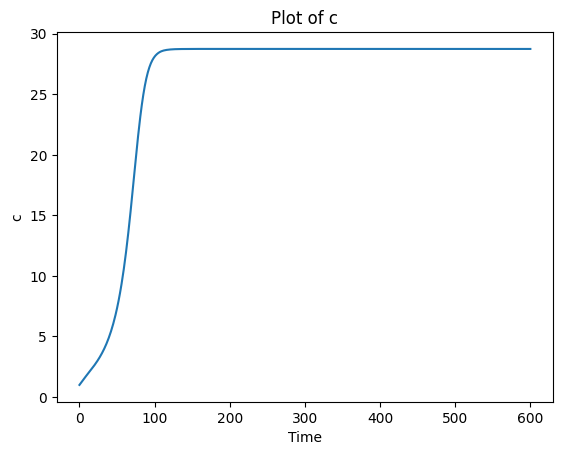

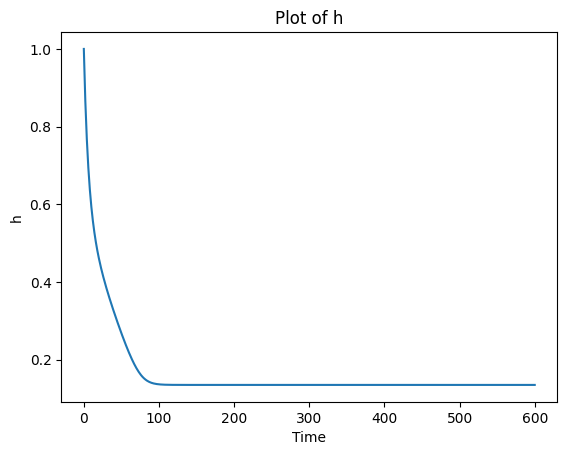

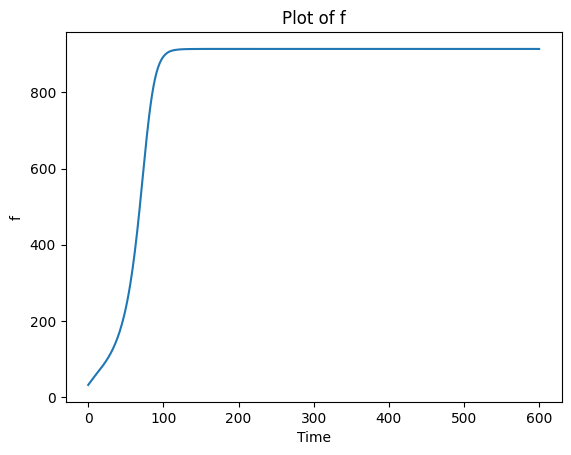

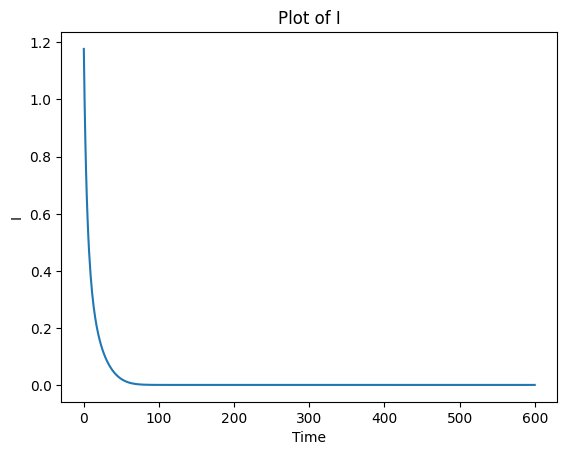

In [15]:
n = np.random.randint(0, len(data_h))
print(n)
print(f"Parameters for n={n}:")
print(f"J_e: {J_e_values[n]}")
print(f"b_1: {b_1_values[n]}")
print(f"b_2: {b_2_values[n]}")
print(f"h_e: {h_e_values[n]}")
print(f"f_0: {f_0_values[n]}")
print(f"P_c: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()